# DeBERTa-v3 + RAG + LLM Judge on SQuAD v2.0 dataset

## 0) Imports

Libraries and PyTorch/HuggingFace modules used throughout the notebook:

In [1]:
import os
import json
import time
import re
import string
import collections
from collections import Counter, defaultdict
from datetime import datetime
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, Subset

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    DebertaV2ForQuestionAnswering,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from safetensors import safe_open

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import seaborn as sns
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from groq import Groq

/opt/anaconda3/envs/tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Dataset Loading and Flattening

SQuAD 2.0 (Rajpurkar et al., 2018) is distributed as a nested JSON with the hierarchy `data → articles → paragraphs → qas`. `squad2_to_df` linearises it into a flat DataFrame where each row represents exactly one question–answer pair.

**Output schema — 8 columns per row:**

| Column | Type | Description |
|--------|------|-------------|
| `id` | str | Unique question identifier |
| `title` | str | Wikipedia article title |
| `paragraph_id` | str | Unique paragraph key (`title__index`) |
| `context` | str | The passage of text |
| `question` | str | The question |
| `can_answer` | `'yes'`/`'no'` | Whether the question is answerable |
| `answer_text` | str | Answer string, or `'NO_ANSWER'` |
| `answer_start` | int | Character offset in context, or `-1` for unanswerable |

**SQuAD 2.0 key property:** approximately 50% of questions are marked `is_impossible=True`, meaning no span in the passage answers the question. The model must learn to predict the `[CLS]` token as start/end position for these cases rather than hallucinating a span.


In [3]:
def squad2_to_df(path: str) -> pd.DataFrame:
    """
    Flattens the nested SQuAD 2.0 JSON into a one row per QA pair DataFrame.
    Args:
        path: path to the SQuAD 2.0 JSON file.
    Returns:
        DataFrame with 8 columns — one row per (context, question, answer) triple.
    """
    with open(path, "r", encoding="utf-8") as f:
        squad = json.load(f)

    rows = []  # accumulate one dict per QA pair
    for article in squad["data"]:
        title = article["title"]
        for para_i, para in enumerate(article["paragraphs"]):
            context = para["context"]  # the passage of text
            paragraph_id = f"{title}__{para_i}"  # unique paragraph key

            for qa in para["qas"]:
                qid = qa["id"]
                question = qa["question"]
                is_impossible = qa.get("is_impossible", False)  # True for ~50% of SQuAD 2.0 questions
                can_answer = "yes" if not is_impossible else "no"  # binary answerability label

                if can_answer == "yes" and len(qa.get("answers", [])) > 0:
                    answer_text  = qa["answers"][0]["text"]   # text of the first annotator answer
                    answer_start = qa["answers"][0]["answer_start"]  # character offset in context
                else:
                    answer_text  = "NO_ANSWER"  # sentinel for unanswerable questions
                    answer_start = -1  # sentinel: no offset for unanswerable questions

                rows.append({
                    "id":           qid,
                    "title":        title,
                    "paragraph_id": paragraph_id,
                    "context":      context,
                    "question":     question,
                    "can_answer":   can_answer,
                    "answer_text":  answer_text,
                    "answer_start": answer_start
                })

    return pd.DataFrame(rows)

train_df = squad2_to_df("Data/train_sampled.json")
val_df   = squad2_to_df("Data/val_sampled.json")
test_df  = squad2_to_df("Data/test_sampled.json")


print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (70807, 8)
Val shape:   (8913, 8)
Test shape:  (8990, 8)


## 2) Tokenisation Pipeline: Overlapping Chunks and Span Alignment

### 2.1) SentencePiece Tokenisation and the Sliding Window

This block converts raw text DataFrames into tokenized inputs suitable for DeBERTa question answering. Since contexts can be longer than the model's maximum input length (384 tokens), each
example is split into overlapping chunks using a sliding window (**stride=128**). For each chunk, the answer's start and end token positions are computed using character-level offset mappings.
Unanswerable questions are assigned start=0 and end=0 (the [CLS] token position).

DeBERTa uses a **SentencePiece tokenizer**, which splits text into subword units rather than whole words. This allows the model to handle any word, even ones never seen during pre-training, by breaking them into smaller known pieces.

Instead of treating each word as a single unit, SentencePiece splits words into subword tokens. The "##" prefix indicates that a token is a continuation of the previous one:

-  "playing"      → ["play", "##ing"]

- "unbelievable" → ["un", "##believe", "##able"]

- "Eiffel"       → ["Ei", "##ff", "##el"]

This means the tokenizer can represent any word by combining subword pieces, even rare or unknown words.

The tokenizer also adds special tokens to structure the input:
  - [CLS]: classification token, always at position 0.
    For unanswerable questions, the model points         start and end predictions here.
 - [SEP]: separator between question and context.
 - [PAD]: padding tokens to reach MAX_LENGTH (384).


DeBERTa v3 has a vocabulary of **~128,000 tokens**, covering subwords from many languages. Each token is mapped to a unique integer ID (input_ids) that the model uses as input.

For question answering, we need to map token positions back to character positions in the original text. This is why we use return_offsets_mapping=True. Each token gets a (start_char, end_char) pair indicating its position in the original string:

- Text:    "Gustave Eiffel"
- Tokens:  ["Gust", "##ave", " Ei", "##ff", "##el"]
- Offsets: [(0,4),  (4,7),  (8,10), (10,12), (12,14)]

This mapping is essential for converting the model's token-level predictions (start token, end token) back into the actual answer text from the original context.

If contexts are longer than MAX_LENGTH the tokenizer splits each example into overlapping chunks using the sliding window:

Chunk 1: tokens   0 → 383   
Chunk 2: tokens 256 → 383+256  
Chunk 3: tokens 512 → 383+512

Each chunk overlaps the previous one by 128 tokens, ensuring that answers near chunk boundaries are not missed. This is why the number of tokenized chunks can be greater than the number of original examples.

sequence_ids() returns a list indicating which part of the input each token belongs to:

- None → special token ([CLS], [SEP], [PAD])
-  0    → question token
-  1    → context token

We use this to locate the context window within each chunk and find the exact token positions of the answer span.

### 2.2) Tokenizer Configuration and `tokenize_df`

**Global tokenisation parameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `MODEL_NAME` | `microsoft/deberta-v3-base` | Best accuracy and size trade-off |
| `MAX_LENGTH` | 384 | Maximum tokens per chunk |
| `DOC_STRIDE` | 128 | Overlap between consecutive chunks; ensures answers near boundaries are covered |

**Sliding window mechanics** for longer context than MAX_LENGHT.

**Span alignment algorithm:** `sequence_ids()` identifies context tokens (value `1`) vs question tokens (value `0`) vs special tokens (value `None`). The answer character offsets from SQuAD are converted to token indices by scanning `offset_mapping`. If the gold answer falls outside the current chunk window, that chunk is labelled as unanswerable (`start=0, end=0` = `[CLS]`).

**Why chunk count > example count:** long contexts produce multiple chunks.

In [4]:
## GLOBAL TOKENISATION CONFIGURATION
MODEL_NAME = "microsoft/deberta-v3-base"  # DeBERTa-v3-base: ~184M parameters, SentencePiece vocab ~128k
MAX_LENGTH = 384  # maximum tokens per chunk (question + [SEP] + context + [SEP] + [PAD])
DOC_STRIDE = 128  # overlap between consecutive chunks to avoid missing answers at boundaries

# Load the DeBERTa SentencePiece tokenizer 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_df(df):
    """
    Converts a raw SQuAD DataFrame into tokenized tensors for DebertaV2ForQuestionAnswering.

    Returns a dict with: input_ids, attention_mask, token_type_ids,
    start_positions, end_positions, answerable, sample_map.
    """
    # Step 1: extract raw Python lists for vectorised tokenisation
    questions   = df["question"].tolist()
    contexts    = df["context"].tolist()
    answers     = df["answer_text"].tolist()   # gold answer strings
    starts      = df["answer_start"].tolist()
    answerables = (df["can_answer"] == "yes").astype(int).tolist()

    # Step 2: tokenise all question-context pairs with sliding window
    tokenized = tokenizer(
        questions,
        contexts,
        max_length=MAX_LENGTH,
        truncation="only_second",          # only truncate the context, never the question
        stride=DOC_STRIDE,                 # 128-token overlap so boundary answers are not missed
        return_overflowing_tokens=True,    # produce multiple chunks for contexts > MAX_LENGTH
        return_offsets_mapping=True,       # each token gets a (start_char, end_char) in original string
        padding="max_length",              # right-pad all chunks to MAX_LENGTH (384)
    )

    # Step 3: extract metadata (must NOT be passed to model.forward)
    sample_map     = tokenized.pop("overflow_to_sample_mapping")
    # offset_mapping[i][j] = (start_char, end_char) of token j in chunk i
    offset_mapping = tokenized.pop("offset_mapping")

    start_positions   = []
    end_positions     = []
    final_answerables = []

    # Step 4: compute answer span positions for every chunk
    for i, offsets in enumerate(offset_mapping):
        # Map chunk index -> original DataFrame row index
        sample_idx = sample_map[i]
        answerable = answerables[sample_idx]
        final_answerables.append(answerable)

        # Unanswerable: assign [CLS] (pos 0); model learns to predict [CLS] for no-answer
        if not answerable:
            start_positions.append(0)
            end_positions.append(0)
            continue

        answer_start = starts[sample_idx]
        answer_text  = answers[sample_idx]

        # Guard: treat sentinel values as unanswerable
        if answer_text == "NO_ANSWER" or answer_start == -1:
            start_positions.append(0)
            end_positions.append(0)
            continue

        answer_end   = answer_start + len(answer_text)  # character-level end (exclusive)
        # 0=question token, 1=context token, None=special token ([CLS],[SEP],[PAD])
        sequence_ids = tokenized.sequence_ids(i)

        # Locate the context window: first and last token with sequence_id == 1
        ctx_start = next(j for j, s in enumerate(sequence_ids) if s == 1)
        ctx_end   = len(sequence_ids) - 1
        while sequence_ids[ctx_end] != 1:
            ctx_end -= 1

        # If gold answer lies outside this chunk's window -> label as no-answer
        if offsets[ctx_start][0] > answer_start or offsets[ctx_end][1] < answer_end:
            start_positions.append(0)
            end_positions.append(0)
            continue

        # Scan forward until offset surpasses the answer start char
        start = ctx_start
        while start <= ctx_end and offsets[start][0] <= answer_start:
            start += 1
        start_positions.append(start - 1)  # step back: first token whose offset >= answer_start

        # Retreat until offset falls below the answer end char
        end = ctx_end
        while end >= ctx_start and offsets[end][1] >= answer_end:
            end -= 1
        end_positions.append(end + 1)  # step forward: last token whose offset <= answer_end

    # Step 5: attach labels to the tokenized dict
    tokenized["start_positions"] = start_positions
    tokenized["end_positions"]   = end_positions
    tokenized["answerable"]      = final_answerables
    tokenized["samplem map"]     = sample_map  # note: typo in key kept for compatibility
    return tokenized

# Tokenize all three splits
print("Tokenizing train...")
train_tok = tokenize_df(train_df)
print("Tokenizing val...")
val_tok   = tokenize_df(val_df)
print("Tokenizing test...")
test_tok  = tokenize_df(test_df)

print(f"Train chunks: {len(train_tok['input_ids'])}")
print(f"Val chunks:   {len(val_tok['input_ids'])}")
print(f"Test chunks:  {len(test_tok['input_ids'])}")

Tokenizing train...
Tokenizing val...
Tokenizing test...
Train chunks: 71433
Val chunks:   8997
Test chunks:  9038


### 2.3) HuggingFace Dataset Objects and DataLoaders

After tokenization, the raw Python dictionaries are converted into HuggingFace Dataset objects. This format provides built-in support for batching, shuffling, and efficient iteration during training and evaluation.
Each dataset is then configured to return PyTorch tensors for the five columns required by the model:

- input_ids: the token IDs for each chunk, representing the question and context as a sequence of integers from the DeBERTa vocabulary;
- attention_mask: a binary mask with 1 for real tokens and 0 for padding tokens, telling the model which positions to attend to;
- token_type_ids: segment IDs indicating whether each token belongs to the question (0) or the context (1);
- start_positions: the token index of the answer start, set to 0 for unanswerable questions;
- end_positions: the token index of the answer end, set to 0 for unanswerable questions.

**Why `set_format(type='torch')`?** HuggingFace Datasets store data as Apache Arrow arrays. `set_format` tells the dataset to return PyTorch tensors on `__getitem__` calls, eliminating manual `torch.tensor()` conversion in the DataLoader. The `answerable` column is excluded from the tensor format because it is not part of the model's input signature but is still needed for metric computation.

In [5]:
# Convert tokenized dicts to HuggingFace Dataset objects
# Dataset.from_dict wraps a Python dict of lists into an Arrow-backed Dataset
train_dataset = Dataset.from_dict(train_tok)
val_dataset   = Dataset.from_dict(val_tok)
test_dataset  = Dataset.from_dict(test_tok)

# Only these 5 columns are needed by the model's forward() method
cols = ["input_ids", "attention_mask", "token_type_ids", "start_positions", "end_positions"]

# set_format makes __getitem__ return torch.Tensor for the specified columns
train_dataset.set_format(type="torch", columns=cols)
val_dataset.set_format(type="torch",   columns=cols)
test_dataset.set_format(type="torch",  columns=cols)

print("Train dataset:", len(train_dataset))
print("Val dataset:  ", len(val_dataset))
print("Test dataset: ", len(test_dataset))

Train dataset: 71433
Val dataset:   8997
Test dataset:  9038


## 3) Model: DeBERTa-v3 for Question Answering

### 3.1) DeBERTa-v3 Architecture Overview

DeBERTa-v3 (He et al., 2021) extends BERT with three key innovations:

#### 3.1.1) Disentangled Attention

In standard BERT, each token is represented by a **single vector** that conflates two distinct pieces of information: what the token *means* (content) and where it *sits* in the sequence (position). DeBERTa disentangles these into two separate vectors per token:

- $H_i^c \in \mathbb{R}^d$ — the **content vector** of token $i$ (its semantic representation)
- $P_{i-j} \in \mathbb{R}^d$ — the **relative position vector** encoding the distance between token $i$ and token $j$ (e.g. "token $j$ is 3 positions to the right of token $i$")

The attention score between token $i$ (query) and token $j$ (key) is then the sum of **three dot products**, each capturing a different type of interaction:

$$A_{i,j} = \frac{1}{\sqrt{3d}}\left(\underbrace{H_i^c\, H_j^{c\top}}_{\text{content-to-content}} + \underbrace{H_i^c\, P_{i-j}^{\top}}_{\text{content-to-position}} + \underbrace{P_{i-j}\, H_j^{c\top}}_{\text{position-to-content}}\right)$$

**Breaking down each term:**

| Term | Query | Key | What it captures |
|------|-------|-----|-----------------|
| $H_i^c H_j^{c\top}$ | content of $i$ | content of $j$ | *"How semantically related are these two tokens?"* e.g. `bank` attends strongly to `river` |
| $H_i^c P_{i-j}^{\top}$ | content of $i$ | relative position of $j$ w.r.t. $i$ | *"Given what token $i$ means, how much should it attend to tokens at distance $i{-}j$?"* e.g. a verb attending to nearby nouns |
| $P_{i-j} H_j^{c\top}$ | relative position of $j$ w.r.t. $i$ | content of $j$ | *"Given that token $j$ is at relative distance $i{-}j$, how relevant is its content?"* e.g. a token strongly influenced by whatever appears immediately before it |

The $\frac{1}{\sqrt{3d}}$ normalisation factor scales down the sum of three dot products (instead of the usual $\frac{1}{\sqrt{d}}$ for a single dot product) to prevent the pre-softmax scores from growing too large and saturating the softmax.

#### 3.1.2) Enhanced Mask Decoder (EMD)

Disentangled attention uses only **relative** position. This is powerful for modelling local dependencies, but it creates an ambiguity: two identical tokens at completely different absolute positions in the sentence receive identical representations throughout the transformer stack, because nothing tells them where they are in absolute terms.

The EMD resolves this by injecting **absolute position embeddings** $E_i^{abs}$ (the same kind BERT uses) at a single strategic point: the input to the **final transformer layer only**, just before the prediction head. All intermediate layers see only relative positions and content.

$$H^{(L)}_{\text{input}} = H^{(L-1)} + E^{abs}$$

where $H^{(L-1)}$ is the output of the second-to-last layer and $E^{abs}$ is the absolute position embedding matrix.

Why not add absolute position at every layer, like BERT?
Adding it early forces every intermediate layer to mix content, relative position, and absolute position together from the start. Keeping them separate for $L{-}1$ layers allows the model to learn cleaner semantic representations; absolute position is introduced only at the last moment when the model actually needs to distinguish identical tokens that sit at different places in the sequence.


#### 3.1.3) ELECTRA-style Pre-training (Replaced Token Detection)

Standard BERT pre-training uses **Masked Language Modelling (MLM)**: ~15% of tokens are replaced with `[MASK]` and the model learns to predict the original token. The problem is that only those 15% of positions generate a training signal — the other 85% contribute nothing to the loss, which is computationally wasteful.

DeBERTa-v3 adopts the **Replaced Token Detection (RTD)** objective from ELECTRA (Clark et al., 2020):

1. A small **generator** (a lightweight model trained with standard MLM) samples plausible replacements for a subset of tokens.
2. The main **discriminator** (DeBERTa itself) receives the corrupted sequence and must classify every single token as either `original` or `replaced`.

This makes RTD significantly more sample-efficient: DeBERTa-v3 matches or outperforms models trained with much more compute when using MLM.

The generator is kept small and is trained with MLM (not RTD), so its samples are plausible but imperfect. The discriminator's task remains non-trivial because the replacements are semantically coherent (making false negatives easy to miss) yet subtly wrong.

#### 3.1.4) Extractive QA: `DebertaV2ForQuestionAnswering`

The HuggingFace class adds a single **linear projection** (the "QA head") on top of DeBERTa's final hidden states:

$$\text{start\_logits} = W_s H, \qquad \text{end\_logits} = W_e H$$

where:
- $H \in \mathbb{R}^{B \times L \times d}$ — the final hidden state matrix; $B$ = batch size, $L$ = sequence length (up to 384 tokens), $d$ = hidden dimension (768 for base)
- $W_s, W_e \in \mathbb{R}^{d \times 1}$ — two learned weight vectors (one for start, one for end), applied independently to every token position
- The output $\text{start\_logits}, \text{end\_logits} \in \mathbb{R}^{B \times L}$ — one unnormalised score per token per sequence

The predicted answer span is the pair $(s^*, e^*)$ that maximises:

$$s^*, e^* = \underset{s \leq e}{\arg\max}\left[\text{start\_logit}_s + \text{end\_logit}_e\right]$$

**Training loss** is the average cross-entropy over the two independent classification tasks (start position and end position):

$$\mathcal{L} = -\frac{1}{2}\Bigl(\log P(s^*) + \log P(e^*)\Bigr)$$

where $P(s^*) = \text{softmax}(\text{start\_logits})_{s^*}$ is the probability the model assigns to the correct start token, and similarly for $P(e^*)$.

**Unanswerable questions (SQuAD 2.0):** when no answer exists in the passage, the ground truth labels are set to $s^* = 0,\ e^* = 0$, i.e. the `[CLS]` token at position 0. The model therefore learns that a high score at position 0 signals that cannot find an answer.

### 3.2) Loading Pre-trained Weights

The fine-tuned model weights are available on the project [Google Drive](https://drive.google.com/drive/folders/1qrieC-mHhRIrC2OecUTZwMuXtSQfHDb3). Download `deberta_squad_finetuned` and load it directly to skip training.

Run this cell instead of **Section 3.2** — the two are mutually exclusive.

In [7]:
# Update this path to the folder containing the fine-tuned model weights
MODEL_PATH = "./deberta_squad_finetuned" 

# Select device: MPS (Apple Silicon), CUDA, or CPU
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

# AutoModelForQuestionAnswering infers the correct architecture from config.json
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_PATH)
# Load the SentencePiece tokenizer saved with the model
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model.to(device)   # move all parameters to the selected device
model.eval()       # disable dropout for deterministic inference

print("Model loaded successfully")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 7758.32it/s]


Model loaded successfully


### 3.3) Training

The training procedure was carried out for a maximum of **3 epochs** using DeBERTa. 

During training, the model’s performance was monitored using two main metrics:

- **Training and validation loss**, used to evaluate convergence.
- **Macro F1 score**, computed on the answerability classification task (i.e., predicting whether a question has an answer in the context).

The answerability prediction was derived from the predicted start token, considering the prediction as *answerable* when the predicted start position was different from the `[CLS]` token.

This monitoring strategy allows us to track:

- whether the model is learning meaningful span representations (through loss reduction),
- whether it is correctly distinguishing answerable and unanswerable questions (through the macro F1 score).

Finally, the best-performing model according to the lowest validation loss was stored and later used for the final evaluation phase on the test set.

**Hyperparameter rationale:**

| Hyperparameter | Value | Why |
|---|---|---|
| `LR` | `4e-5` | Standard fine-tuning LR for DeBERTa-base |
| `weight_decay` | `0.01` | L2 regularisation via AdamW to prevent overfitting |
| Warmup | 20% of steps | Linear warmup avoids large updates early in training |
| `BATCH_SIZE` | 32 | Fits on 32 GB VRAM GPU; provides stable gradient estimates |
| `EPOCHS` | 3 | Standard for BERT-family fine-tuning; more risks overfitting |
| `grad_clip` | 1.0 | Clips gradient L2 norm; prevents exploding updates |
| `MAX_PATIENCE` | 2 | Early stopping after 2 non-improving epochs based on validation loss |

**AdamW update rule** (Loshchilov & Hutter, 2019) decouples weight decay from the adaptive learning rate:

$$\theta_{t+1} = \theta_t - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} - \alpha \lambda \theta_t$$

where $\hat{m}_t$, $\hat{v}_t$ are bias-corrected first and second moment estimates and $\lambda$ is the weight decay coefficient. The final term applies direct weight shrinkage independently of the adaptive step size — more effective than vanilla Adam's L2 penalty for transformers.

**Answerability proxy during training:** instead of adding a dedicated classification head,
we derive a free binary signal from the existing start logits:

- If `argmax(start_logits) == 0` → model points to `[CLS]` → predicted **unanswerable**
- If `argmax(start_logits) != 0` → model points to a content token → predicted **answerable**

**Macro F1** is used instead of accuracy because the dataset is ~50/50 answerable/unanswerable
— a model predicting "always answerable" would already score ~58% accuracy, making it a
misleading metric. Macro F1 penalises class collapse equally for both classes.

**Every 50 steps** rather than once per epoch, so we can catch early failure modes
(e.g. the model stuck predicting one class) without waiting ~2 200 steps.

In [20]:
## TRAINING HYPERPARAMETERS
EPOCHS     = 3    # fine-tuning epochs (3 is standard for BERT-family on SQuAD)
BATCH_SIZE = 32   # examples per gradient update
LR         = 4e-5  # learning rate; typical range for DeBERTa fine-tuning: [2e-5, 5e-5]
SAVE_PATH  = "/workspace/deberta_squad_finetuned" # Update to your actual output path

# Prefer CUDA; fall back to CPU if unavailable
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Load DeBERTa-v3-base with a QA head (two linear layers for start/end logits)
model = DebertaV2ForQuestionAnswering.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
model.to(device)

# shuffle=True randomises order each epoch -- essential for SGD-based optimisers
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)  # no shuffle for reproducible evaluation

# AdamW: Adam + decoupled weight decay 
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS  # total gradient updates across all epochs
# Linear warmup from 0 to LR over 20% of steps, then linear decay to 0
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.2 * total_steps),   # 20% of total steps for warmup phase
    num_training_steps=total_steps
)

# Early stopping state
best_val_loss = float("inf")  # best validation loss seen so far
patience      = 0   # consecutive epochs without improvement
MAX_PATIENCE  = 2   # stop after 2 consecutive non-improving epochs

for epoch in range(EPOCHS):
    model.train()  # enable dropout for training
    total_loss  = 0
    step_preds  = []
    step_labels = []

    for step, batch in enumerate(train_loader):
        batch   = {k: v.to(device) for k, v in batch.items()}  # move tensors to GPU
        outputs = model(**batch)  # forward pass: returns start_logits, end_logits, loss
        loss    = outputs.loss    # combined cross-entropy for start and end positions

        loss.backward()  # backpropagate: compute gradients for all parameters
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # clip gradient L2 norm to 1.0
        optimizer.step()   # update parameters
        scheduler.step()   # advance LR schedule
        optimizer.zero_grad()  # clear gradients for next step

        with torch.no_grad():
            # Answerability proxy: predicted start != 0 means model predicts a span exists
            pred_starts = outputs.start_logits.argmax(dim=-1)  # (B,)
            preds  = (pred_starts != 0).long().cpu().tolist()   # 1=answerable, 0=not
            labels = (batch["start_positions"] != 0).long().cpu().tolist()  # gold labels
            step_preds.extend(preds)
            step_labels.extend(labels)

        total_loss += loss.item()

        # Log macro F1 every 50 steps to monitor answerability learning progress
        if step % 50 == 0 and step > 0:
            f1 = f1_score(step_labels, step_preds, average="macro", zero_division=0)
            print(f"Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f} | F1: {f1:.4f}")
            step_preds  = []
            step_labels = []

    avg_train_loss = total_loss / len(train_loader)  # average loss across batches this epoch

    # Validation pass
    model.eval()  # disable dropout for deterministic validation
    val_loss   = 0
    val_preds  = []
    val_labels = []

    with torch.no_grad():
        for batch in val_loader:
            batch   = {k: v.to(device) for k, v in batch.items()}  # move tensors to GPU
            outputs = model(**batch)
            val_loss += outputs.loss.item()

            # Answerability proxy: predicted start != 0 means model predicts a span exists
            pred_starts = outputs.start_logits.argmax(dim=-1)  # (B,)
            preds  = (pred_starts != 0).long().cpu().tolist()   # 1=answerable, 0=not
            labels = (batch["start_positions"] != 0).long().cpu().tolist()  # gold labels
            val_preds.extend(preds)
            val_labels.extend(labels)

    avg_val_loss = val_loss / len(val_loader)
    val_f1       = f1_score(val_labels, val_preds, average="macro", zero_division=0)

    print(f"\n=== Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f} ===\n")

    # Checkpoint and early stopping
    if avg_val_loss < best_val_loss:  # improvement -> save and reset patience
        best_val_loss = avg_val_loss
        patience      = 0   # consecutive epochs without improvement
        model.save_pretrained(SAVE_PATH)     # saves config.json + model.safetensors
        tokenizer.save_pretrained(SAVE_PATH) # saves tokenizer_config + sentencepiece model
        print(f"Saved model (val loss: {best_val_loss:.4f})\n")
    else:  # no improvement: increment patience counter
        patience += 1
        print(f"No improvement. Patience: {patience}/{MAX_PATIENCE}\n")
        if patience >= MAX_PATIENCE:
            print("Early stopping triggered.")
            break  # use the best checkpoint saved above

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForQuestionAnswering LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
qa_outputs.weight                       | MISSING    | 
qa_outputs.bias                         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; no

Epoch 1 | Step 50/2233 | Loss: 5.1587 | F1: 0.3925
Epoch 1 | Step 100/2233 | Loss: 4.0251 | F1: 0.5091
Epoch 1 | Step 150/2233 | Loss: 3.2044 | F1: 0.3993
Epoch 1 | Step 200/2233 | Loss: 3.6340 | F1: 0.3325
Epoch 1 | Step 250/2233 | Loss: 3.0292 | F1: 0.3316
Epoch 1 | Step 300/2233 | Loss: 2.6207 | F1: 0.3494
Epoch 1 | Step 350/2233 | Loss: 2.5543 | F1: 0.4330
Epoch 1 | Step 400/2233 | Loss: 1.9712 | F1: 0.4531
Epoch 1 | Step 450/2233 | Loss: 1.1305 | F1: 0.5346
Epoch 1 | Step 500/2233 | Loss: 1.8200 | F1: 0.5415
Epoch 1 | Step 550/2233 | Loss: 1.6589 | F1: 0.5806
Epoch 1 | Step 600/2233 | Loss: 1.2935 | F1: 0.6305
Epoch 1 | Step 650/2233 | Loss: 1.8893 | F1: 0.6352
Epoch 1 | Step 700/2233 | Loss: 1.2234 | F1: 0.6673
Epoch 1 | Step 750/2233 | Loss: 1.4707 | F1: 0.7017
Epoch 1 | Step 800/2233 | Loss: 1.2523 | F1: 0.7084
Epoch 1 | Step 850/2233 | Loss: 1.1422 | F1: 0.7586
Epoch 1 | Step 900/2233 | Loss: 1.4647 | F1: 0.7339
Epoch 1 | Step 950/2233 | Loss: 1.0300 | F1: 0.7395
Epoch 1 | Ste

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model (val loss: 0.7764)

Epoch 2 | Step 50/2233 | Loss: 0.4953 | F1: 0.8886
Epoch 2 | Step 100/2233 | Loss: 0.8146 | F1: 0.8735
Epoch 2 | Step 150/2233 | Loss: 0.7001 | F1: 0.8869
Epoch 2 | Step 200/2233 | Loss: 1.4711 | F1: 0.8793
Epoch 2 | Step 250/2233 | Loss: 0.7919 | F1: 0.8847
Epoch 2 | Step 300/2233 | Loss: 0.6886 | F1: 0.8797
Epoch 2 | Step 350/2233 | Loss: 1.0286 | F1: 0.8744
Epoch 2 | Step 400/2233 | Loss: 0.7753 | F1: 0.8774
Epoch 2 | Step 450/2233 | Loss: 0.7176 | F1: 0.8908
Epoch 2 | Step 500/2233 | Loss: 0.7391 | F1: 0.8866
Epoch 2 | Step 550/2233 | Loss: 0.6812 | F1: 0.8814
Epoch 2 | Step 600/2233 | Loss: 0.6671 | F1: 0.8818
Epoch 2 | Step 650/2233 | Loss: 0.6038 | F1: 0.8912
Epoch 2 | Step 700/2233 | Loss: 0.5221 | F1: 0.8957
Epoch 2 | Step 750/2233 | Loss: 0.8672 | F1: 0.8978
Epoch 2 | Step 800/2233 | Loss: 0.6176 | F1: 0.8975
Epoch 2 | Step 850/2233 | Loss: 0.2449 | F1: 0.9078
Epoch 2 | Step 900/2233 | Loss: 0.5133 | F1: 0.9023
Epoch 2 | Step 950/2233 | Loss: 0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model (val loss: 0.6675)

Epoch 3 | Step 50/2233 | Loss: 0.6581 | F1: 0.9417
Epoch 3 | Step 100/2233 | Loss: 0.3609 | F1: 0.9393
Epoch 3 | Step 150/2233 | Loss: 0.3754 | F1: 0.9437
Epoch 3 | Step 200/2233 | Loss: 0.4480 | F1: 0.9466
Epoch 3 | Step 250/2233 | Loss: 0.4888 | F1: 0.9529
Epoch 3 | Step 300/2233 | Loss: 0.5210 | F1: 0.9492
Epoch 3 | Step 350/2233 | Loss: 0.4271 | F1: 0.9551
Epoch 3 | Step 400/2233 | Loss: 0.5392 | F1: 0.9447
Epoch 3 | Step 450/2233 | Loss: 0.5271 | F1: 0.9581
Epoch 3 | Step 500/2233 | Loss: 0.3194 | F1: 0.9538
Epoch 3 | Step 550/2233 | Loss: 0.3500 | F1: 0.9511
Epoch 3 | Step 600/2233 | Loss: 0.4018 | F1: 0.9447
Epoch 3 | Step 650/2233 | Loss: 0.7332 | F1: 0.9490
Epoch 3 | Step 700/2233 | Loss: 0.2572 | F1: 0.9461
Epoch 3 | Step 750/2233 | Loss: 0.5495 | F1: 0.9524
Epoch 3 | Step 800/2233 | Loss: 0.5838 | F1: 0.9485
Epoch 3 | Step 850/2233 | Loss: 0.3925 | F1: 0.9466
Epoch 3 | Step 900/2233 | Loss: 0.4760 | F1: 0.9429
Epoch 3 | Step 950/2233 | Loss: 0

## 4) Test Set Evaluation

### 4.1) Inference, Answerability Classification and Span Metrics

This cell evaluates the fine-tuned model on the held-out test set across two tasks:

**A) Answerability classification** — proxy rule: `argmax(start_logits) != 0` predicts answerable. 

**B) Span extraction metrics** (answerable examples only):

- **Exact Match (EM):** $\text{EM} = \mathbf{1}[\text{norm}(\hat{a}) = \text{norm}(a)]$ = 1 only if the normalised prediction matches the gold answer exactly, otherwise 0.

- **Token F1:** $F_1 = \frac{2 P R}{P + R}$ where
  $P = \frac{|\text{pred} \cap \text{gold}|}{|\text{pred}|}$ and   $R = \frac{|\text{pred} \cap \text{gold}|}{|\text{gold}|}$, token-level bag-of-words overlap

**Span selection per chunk:**

$$s^*, e^* = \arg\max_{s \geq 1,\, e \geq s} \left[ \text{start\_logit}_s + \text{end\_logit}_e \right]$$

If the null score $\text{start\_logit}_0 + \text{end\_logit}_0$ exceeds the best span score, the prediction is empty (unanswerable).

**Normalisation:** lowercase, remove articles (`a`, `an`, `the`), remove punctuation, collapse spaces.

In [25]:
# Select compute device (change to 'cuda' if a GPU is available)
device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
model.eval()  # disable dropout: outputs are deterministic

# Small batch size avoids OOM -- no gradients stored during inference
test_loader = DataLoader(test_dataset, batch_size=8)

all_preds        = []
all_labels       = []
all_start_logits = []
all_end_logits   = []
all_start_labels = []
all_end_labels   = []

# torch.no_grad() skips gradient computation: ~2x faster and lower GPU memory
with torch.no_grad():
    for batch in test_loader:
        batch   = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)

        # Answerability proxy: argmax != 0 means model found a span
        pred_starts = outputs.start_logits.argmax(dim=-1)  # (B,) predicted start positions
        preds  = (pred_starts != 0).long().cpu().tolist()  # 1=answerable, 0=not
        labels = (batch["start_positions"] != 0).long().cpu().tolist()  # gold labels
        all_preds.extend(preds)
        all_labels.extend(labels)

        all_start_logits.extend(outputs.start_logits.cpu().tolist())
        all_end_logits.extend(outputs.end_logits.cpu().tolist())
        all_start_labels.extend(batch["start_positions"].cpu().tolist())
        all_end_labels.extend(batch["end_positions"].cpu().tolist())

print("=== Answerability Classification ===")
print(classification_report(all_labels, all_preds, target_names=["unanswerable", "answerable"]))

# Official SQuAD 2.0 normalisation and scoring functions
def normalize_answer(s):
    """Lowercase, remove articles, remove punctuation, collapse whitespace."""
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = ''.join(ch for ch in s if ch not in string.punctuation)
    s = ' '.join(s.split())
    return s

def get_tokens(s):
    """Returns the list of normalised tokens for a string."""
    return normalize_answer(s).split()

def compute_exact(pred, gold):
    """Returns 1 if normalised pred equals normalised gold, else 0."""
    return int(normalize_answer(pred) == normalize_answer(gold))

def compute_f1(pred, gold):
    """Token-level F1: harmonic mean of precision and recall over bag-of-words overlap."""
    pred_tokens = get_tokens(pred)
    gold_tokens = get_tokens(gold)
    common      = collections.Counter(pred_tokens) & collections.Counter(gold_tokens)  # multiset intersection
    num_same    = sum(common.values())  # total overlapping tokens (duplicates handled correctly)
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)  # fraction of pred tokens that are correct
    recall    = num_same / len(gold_tokens)  # fraction of gold tokens that are found
    return (2 * precision * recall) / (precision + recall)

# Compute span metrics on answerable examples only
# (unanswerable: start_true==0 -> no span to evaluate)
em_scores = []
f1_scores = []

for i in range(len(all_start_logits)):
    start_true = all_start_labels[i]
    end_true   = all_end_labels[i]

    # Skip unanswerable
    if start_true == 0:
        continue

    start_logits = torch.tensor(all_start_logits[i])
    end_logits   = torch.tensor(all_end_logits[i])

    null_score = start_logits[0] + end_logits[0]  # score for predicting no answer
    best_start = int(start_logits[1:].argmax()) + 1  # best non-[CLS] start position
    best_end   = int(end_logits[1:].argmax()) + 1  # best non-[CLS] end position
    best_score = start_logits[best_start] + end_logits[best_end]  # span score

    # If null score wins, model predicts no answer
    if null_score > best_score:
        pred_text = ""  # empty = unanswerable
    else:
        if best_end < best_start:
            best_end = best_start  # safeguard: end cannot precede start
        input_ids = test_dataset[i]["input_ids"].tolist()
        # Decode token IDs back to text; skip_special_tokens removes [CLS],[SEP],[PAD]
        pred_text = tokenizer.decode(input_ids[best_start:best_end + 1], skip_special_tokens=True)

    input_ids = test_dataset[i]["input_ids"].tolist()
    gold_text = tokenizer.decode(input_ids[start_true:end_true + 1], skip_special_tokens=True)

    em_scores.append(compute_exact(pred_text, gold_text))
    f1_scores.append(compute_f1(pred_text, gold_text))

print(f"\n=== QA Span Metrics (just answerable) ===")
print(f"Exact Match (EM): {sum(em_scores)/len(em_scores):.4f}")
print(f"F1 Score:         {sum(f1_scores)/len(f1_scores):.4f}")
print(f"Support:  {len(em_scores)}")

=== Answerability Classification ===
              precision    recall  f1-score   support

unanswerable       0.91      0.89      0.90      3798
  answerable       0.92      0.93      0.93      5240

    accuracy                           0.92      9038
   macro avg       0.91      0.91      0.91      9038
weighted avg       0.92      0.92      0.92      9038


=== QA Span Metrics (just answerable) ===
Exact Match (EM): 0.6767
F1 Score:         0.8006
Support:  5240


- Answerability macro F1 > 0.85: both classes are accurately classified
- Span EM ~0.68: ~68% of predictions are character-perfect matches
- Span F1 ~0.80: even failed EM predictions often capture most correct tokens
- Span F1 > EM: always expected — F1 gives partial credit, EM is binary

### 4.2) Confusion Matrix — Answerability

=== Confusion Matrix ===
[[3380  418]
 [ 348 4892]]


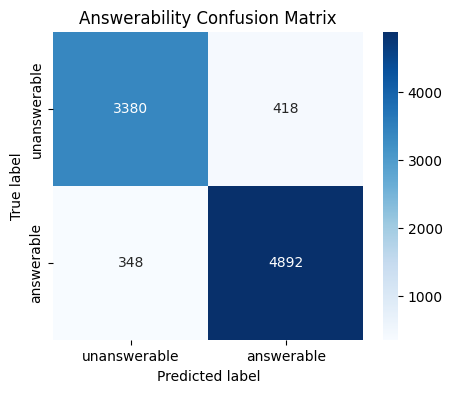

In [26]:
# Build and display answerability confusion matrix
# Row = gold label, Column = predicted label
cm = confusion_matrix(all_labels, all_preds)

print("=== Confusion Matrix ===")
print(cm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,    # show count values in each cell
    fmt="d",      # integer format for counts
    cmap="Blues",  # sequential blue colormap: darker = higher count
    xticklabels=["unanswerable", "answerable"],
    yticklabels=["unanswerable", "answerable"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Answerability Confusion Matrix")
plt.show()

### 4.3) Model in Action

`answer_question` wraps the full inference pipeline: tokenisation → sliding window → forward pass → best span selection across chunks.

**Multi-chunk span selection:** the model runs independently on each chunk and keeps the answer with the highest score $\text{start\_logit}_s + \text{end\_logit}_e$ across all chunks.

In [8]:
def answer_question(question, context, model, tokenizer, device, max_length=384, doc_stride=128):
    """
    End-to-end QA inference on a single (question, context) pair.
    Handles long contexts via sliding window and selects the best answer span
    across all chunks based on combined start+end logit score.
    """
    model.eval()  # ensure dropout is disabled

    inputs = tokenizer(
        question,
        context,
        max_length=max_length,
        truncation="only_second",
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
        return_tensors="pt"
    )

    # Remove metadata not accepted by model.forward()
    offset_mapping = inputs.pop("offset_mapping")   # (num_chunks, seq_len, 2)
    sample_map     = inputs.pop("overflow_to_sample_mapping")  # chunk -> example index

    inputs = {k: v.to(device) for k, v in inputs.items()}  # move to GPU/MPS

    with torch.no_grad():
        outputs = model(**inputs)

    # Track the globally best span score across all chunks
    best_score  = -float("inf")
    best_answer = ""

    for i in range(len(outputs.start_logits)):
        start_logits = outputs.start_logits[i]
        end_logits   = outputs.end_logits[i]
        offsets      = offset_mapping[i]

        # Null score = logit(start=[CLS]) + logit(end=[CLS])
        null_score = start_logits[0] + end_logits[0]

        # Best non-null span: argmax excluding [CLS] position 0
        best_start = int(start_logits[1:].argmax()) + 1
        best_end   = int(end_logits[1:].argmax()) + 1
        span_score = start_logits[best_start] + end_logits[best_end]

        # Keep the globally best span across all chunks
        if span_score > best_score:
            best_score = span_score.item()

            # Null score wins -> no answer
            if null_score > span_score:
                best_answer = "The model cannot answer to this question."
            else:
                if best_end < best_start:
                    best_end = best_start
                # Convert token positions back to character offsets
                start_char = offsets[best_start][0].item()
                end_char   = offsets[best_end][1].item()
                best_answer = context[start_char:end_char]  # slice answer from original text

    return best_answer


# ── Examples ──────────────────────────────────────
context = """
The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.
It is named after the engineer Gustave Eiffel, whose company designed and built the tower
from 1887 to 1889. The tower is 330 metres tall and was the tallest man-made structure in
the world for 41 years.
"""

# Question with answer
question1 = "How tall is the Eiffel Tower?"
answer1   = answer_question(question1, context, model, tokenizer, device)
print(f"Q: {question1}")
print(f"A: {answer1}\n")

# Question without answer
question2 = "Who is the president of France?"
answer2   = answer_question(question2, context, model, tokenizer, device)
print(f"Q: {question2}")
print(f"A: {answer2}\n")

# Question about a fact present in the context
question3 = "Who designed the Eiffel Tower?"
answer3   = answer_question(question3, context, model, tokenizer, device)
print(f"Q: {question3}")
print(f"A: {answer3}\n")

# Question about a fact not present in the context
question4 = "When was the Eiffel Tower painted red?"
answer4   = answer_question(question4, context, model, tokenizer, device)
print(f"Q: {question4}")
print(f"A: {answer4}\n")

Q: How tall is the Eiffel Tower?
A:  330 metres tall

Q: Who is the president of France?
A: The model cannot answer to this question.

Q: Who designed the Eiffel Tower?
A:  Gustave Eiffel

Q: When was the Eiffel Tower painted red?
A: The model cannot answer to this question.



All four predictions are correct. The span precision for `"330 metres"` and `"Gustave Eiffel"` illustrates the quality advantage of DeBERTa's contextualised representations compared to the GloVe-based BiDAF.

### 4.4) Model Comparison: DeBERTa-v3 vs BiLSTM + BiDAF

Both models tackle the same task but represent fundamentally different eras of NLP. BiDAF is a carefully
engineered architecture built on static word vectors; DeBERTa-v3 is a
large pre-trained transformer fine-tuned on the same data. This section compares the two
along four dimensions: input representation, training, and final performance.

#### 4.4.1) Input Representation

This is the deepest architectural difference between the two models.

**BiDAF — Static Embeddings**
GloVe assigns a **single fixed vector** to each word, determined once during pre-training
and never updated based on context. 

Out-of-vocabulary words (anything not in the 50k GloVe vocabulary) are mapped to a random
uniform vector, which carries no semantic information.

**DeBERTa-v3 — Contextual Embeddings**
DeBERTa produces a different representation for the same token depending on its full
context. After 12 layers of self-attention over the entire input sequence
`[CLS] question [SEP] context [SEP]`, each token's hidden state encodes not just its own
meaning but its relationship to every other token in the sequence. 

This contextualisation is the single largest qualitative advantage of transformer-based
models over BiDAF-style architectures.

#### 4.4.2) Training

| | BiDAF | DeBERTa-v3 |
|---|---|---|
| Pre-training | None (GloVe vectors are fixed) | ELECTRA-style RTD on ~160GB of text |
| Fine-tuning data | ~71k SQuAD 2.0 examples | ~71k SQuAD 2.0 examples (same) |
| Optimiser | Adadelta ($\rho=0.95$) | AdamW ($\text{lr}=4 \times 10^{-5}$, weight decay $0.01$) |
| LR schedule | None (Adadelta is self-normalising) | Linear warmup (20%) + linear decay |
| Epochs | Up to 25 (early stopping, patience 5) | 3 (early stopping, patience 2) |
| Loss | Curriculum-weighted span + answerability | Average cross-entropy (start + end) |
| Parameters trained | ~6M (from scratch) | ~184M (fine-tuned from pre-trained init) |

A key difference is the **curriculum weighting** in BiDAF: because the span loss and the
answerability loss operate on very different scales in early training, fixed weights cause
the model to collapse to always predicting "answerable". The three-phase curriculum
($\text{span\_weight}: 3.0 \to 2.0 \to 1.5$) stabilises training by prioritising span
extraction first.

DeBERTa requires no such curriculum because it starts from a pre-trained initialisation
where the encoder already produces meaningful representations (convergence is much faster
and more stable).

#### 4.4.3) Answerability

SQuAD 2.0 requires the model to abstain on unanswerable questions, which is an explicit
classification task on top of span extraction.

**BiDAF** trains a dedicated **answerability head**: a 3-layer MLP over max-pooled start
representation and question encoding, producing a single sigmoid logit. The threshold is
separately tuned on the validation set (best threshold found: 0.80, giving +1.86% F1 over
the default 0.50).

**DeBERTa** handles answerability implicitly: unanswerable questions are labelled
`start=0, end=0` during training, so the model learns to assign high logit mass to the
`[CLS]` token (position 0) when no answer exists. 

The DeBERTa approach is simpler and achieves better answerability F1 (~0.91 macro)
compared to BiDAF (~0.71 accuracy after threshold tuning).

#### 4.4.4) Results

All numbers are on the same held-out test set (gold-context setting, ~9k examples).

| Metric | BiDAF | DeBERTa-v3 | Δ |
|--------|-------|-----------|---|
| Overall EM | 43.69% | 67.67% | +23.98pp |
| Overall F1 | 51.01% | 80.06% | +29.05pp |
| Span EM (answerable only) | — | 67.67% | — |
| Span F1 (answerable only) | 21.40% | 80.06% | +58.66pp |
| Answerability accuracy | 70.19% | ~91.00% | +20.81pp |

The ~29 percentage point F1 gap is large. The diagnostic span F1 on answerable-only
examples (21.40% for BiDAF vs 80.06% for DeBERTa) is particularly revealing: even when
BiDAF correctly identifies a question as answerable, it struggles to precisely delimit
the answer boundaries. This is a direct consequence of GloVe's static representations:
the model cannot resolve which tokens are semantically most relevant to the question
without contextual embeddings.

BiDAF remains a relevant baseline: it is interpretable, lightweight, and requires no
pre-trained weights making it viable in low-resource or compute-constrained settings.
DeBERTa-v3, however, dominates on every quality metric, with the gap driven almost
entirely by the difference between static and contextual token representations.


# 5) RAG Pipeline 



Retrieval-Augmented Generation (RAG) is a two-stage architecture for Question Answering:

1. **Retrieval** — find the passages most likely to contain the answer
2. **Reading** — run the QA model on those passages and extract the answer span

Without retrieval, the QA model would need to be given the correct context manually (the
"gold context" setting). RAG makes the system self-contained: given only a question, it
searches its own index and answers autonomously.


### 5.1) Hybrid Retrieval

A question like *"Where did the Taliban regroup after 2002?"* needs to find the right passage
among ~16 000 indexed contexts. Two complementary signals are used.

#### 5.1.1) Dense Semantic Retrieval

Contexts are encoded into dense vectors using
[`multi-qa-MiniLM-L6-cos-v1`](https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1),
a 22M-parameter **bi-encoder** from the Sentence Transformers library.

A bi-encoder encodes the query and each document independently through the same network,
producing a fixed-size vector for each. Similarity is then computed as a single dot product
(or cosine similarity) between the two vectors. This is fast enough to search millions of
documents at query time because all document vectors can be pre-computed and stored.  
This contrasts with a *cross-encoder*, which processes the query and document together
and is more accurate but too slow to run over a full index.

**What does `multi-qa-MiniLM-L6-cos-v1` mean?**

| Part | Meaning |
|------|---------|
| `multi-qa` | fine-tuned on multiple QA datasets (MS MARCO, Natural Questions, etc.) specifically for retrieval |
| `MiniLM` | a distilled architecture — 6 transformer layers, hidden size 384, ~22M parameters (vs BERT-base's 12 layers, 768 hidden, ~110M) |
| `L6` | 6 transformer layers |
| `cos-v1` | trained with cosine similarity as the distance metric; vectors should be compared with cosine, not dot product |

The model maps any text to a vector in $\mathbb{R}^{384}$:

$$f(\text{text}) \rightarrow \mathbb{R}^{384}$$

so that semantically similar texts land close together in that space — even if they share
no words. For example:

- *"Where was Napoleon born?"* and *"Napoleon's birthplace was Corsica"* will be nearby
- *"Where was Napoleon born?"* and *"The price of wheat in 1815"* will be far apart

Similarity between query $q$ and context $c$ is measured with **cosine similarity**:

$$s_{\text{semantic}} = \frac{f(q) \cdot f(c)}{\|f(q)\| \cdot \|f(c)\|}  \in [-1, 1]$$

#### 5.1.2) Sparse Lexical Retrieval (TF–IDF)

TF–IDF represents each document as a sparse vector of weighted word frequencies. The weight
of term $j$ in document $i$ is:

$$w_{i,j} = tf_{i,j} \cdot idf_j$$

- $tf_{i,j}$ — **term frequency**: how often term $j$ appears in document $i$; rewards documents that mention the term many times
- $idf_j = \log\!\left(\dfrac{N}{df_j}\right)$ — **inverse document frequency**: $N$ is the total number of documents, $df_j$ is the number of documents containing term $j$; rare terms get a high $idf$ (more informative), common terms like *"the"* get a low $idf$ (less informative)

The vectorizer uses **unigrams and bigrams** (`ngram_range=(1,2)`), so *"national archives"*
is treated as a single feature rather than two separate words, important in QA where
multi-word entities are common.

Lexical similarity between query and document is again cosine similarity, but between sparse
TF–IDF vectors rather than dense neural embeddings.

The two retrievers fail in complementary ways:

| | Dense (MiniLM) | Sparse (TF–IDF) |
|---|---|---|
| Handles paraphrases / synonyms | Yes | No |
| Handles rare proper nouns / codes | No | Yes |
| Requires no exact keyword match | Yes | No |

**Why a hybrid retriever?**

| Retriever | Strength | Weakness |
|---|---|---|
| Dense (semantic) | Paraphrases, synonyms | Misses rare proper nouns |
| Sparse (TF-IDF) | Exact keyword matching | Cannot handle paraphrases |
| **Hybrid** | Best of both | Requires tuned weight alpha |


**Title enrichment:** prepending the article title to each context helps the embedding model capture the document topic even when key terms appear only in the title.

**Deduplication:** SQuAD reuses passages across questions; the `seen` set ensures each unique context is indexed exactly once, preventing duplicate retrieval results.

#### 5.1.3) Hybrid Score

Both scores are normalised to $[0, 1]$ so they contribute on the same scale,
then combined with a weighted sum:

$$\text{retrieval score} = \alpha \cdot s_{\text{semantic}} + (1 - \alpha) \cdot s_{\text{lexical}}, \qquad \alpha = 0.7$$

$\alpha = 0.7$ gives more weight to the semantic signal, which is generally more robust,
while the lexical component (weight $0.3$) acts as a tie-breaker for keyword-heavy questions.
The top $k$ contexts by this combined score are passed to the reader.


### 5.2) Extractive Reading (DeBERTa)

The fine-tuned DeBERTa model receives the question and each retrieved context concatenated as:
```
[CLS] question [SEP] context [SEP] [PAD] ... [PAD]
```

If the context is longer than 384 tokens it is split into overlapping chunks (stride = 128)
so that answers near chunk boundaries are not lost.

The model produces two logit vectors — one score per token for start and end:

$$\text{start\_logits},\ \text{end\_logits} \in \mathbb{R}^{L}$$

The best answer span is the pair $(i, j)$ with $i \leq j$ that maximises:

$$i^*, j^* = \underset{i \leq j}{\arg\max}\left[\text{start\_logit}_i + \text{end\_logit}_j\right]$$

This is run independently on every retrieved context and every chunk. The span with the
highest score across all of them is returned as the final answer.

**Unanswerable detection:** if the null score
$\text{start\_logit}_0 + \text{end\_logit}_0$ (position 0 = `[CLS]`) exceeds the best
span score across all retrieved contexts, the system returns no answer.

### 5.3) Index Construction and Hybrid Retriever

In [9]:
# SentenceTransformers produces fixed-size dense embeddings (384-dim for MiniLM)
# Build the deduplicated context index


all_contexts = []               # raw context strings (used for answer extraction)
all_contexts_with_title = []    # title-enriched contexts (used for indexing)

# Deduplicate: the same Wikipedia passage may appear in multiple splits
seen = set()
for df in [train_df, val_df, test_df]:
    for _, row in df.iterrows():
        ctx   = row["context"]
        title = str(row["title"]).replace("_", " ")  # normalise underscores to spaces
        if ctx not in seen:
            seen.add(ctx)
            all_contexts.append(ctx)
            # Prepend title: helps embedding model understand document topic
            all_contexts_with_title.append(f"{title}. {ctx}")

print(f"Contexts in the index: {len(all_contexts)}")

# Compute dense semantic embeddings
# multi-qa-MiniLM-L6-cos-v1: 22M-param bi-encoder optimised for QA retrieval
# Maps text to R^384 vectors optimised for cosine similarity
print("Loading embedding model...")
embedder = SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")

print("Computing semantic embeddings...")
# Encode all contexts in batches; convert_to_numpy for sklearn compatibility
ctx_embeddings = embedder.encode(
    all_contexts_with_title,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Build TF-IDF lexical index
# ngram_range=(1,2): unigrams and bigrams (e.g. 'national archives' as single feature)
# max_features=50000: keep the 50k most informative n-grams
print("Building TF-IDF index...")
vectorizer   = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(all_contexts_with_title)

# Define the hybrid retrieval function
def retrieve(question, k=10, alpha=0.7):
    """
    Retrieves top-k most relevant contexts using hybrid scoring.
    score = alpha*semantic_similarity + (1-alpha)*lexical_similarity
    Both scores are min-max normalised before combining.
    """
    # Prepend 'question:' prefix -- MiniLM was fine-tuned with this format for queries
    enriched_q = f"question: {question}"

    q_emb      = embedder.encode([enriched_q], convert_to_numpy=True)  # (1, 384)
    sem_scores = cosine_similarity(q_emb, ctx_embeddings).flatten()  # (N_contexts,)

    q_tfidf    = vectorizer.transform([enriched_q])  # sparse (1, vocab_size)
    lex_scores = cosine_similarity(q_tfidf, tfidf_matrix).flatten()  # (N_contexts,)

    # Min-max normalise both scores to [0,1] so they combine on the same scale
    sem_scores = (sem_scores - sem_scores.min()) / (sem_scores.max() - sem_scores.min() + 1e-9)
    lex_scores = (lex_scores - lex_scores.min()) / (lex_scores.max() - lex_scores.min() + 1e-9)

    # Hybrid score: alpha=0.7 favours semantic similarity over lexical
    combined = alpha * sem_scores + (1 - alpha) * lex_scores
    top_k    = combined.argsort()[-k:][::-1]  # indices of top-k contexts, descending
    return [(all_contexts[i], float(combined[i])) for i in top_k]

# Full RAG pipeline: retrieve -> reader -> select best answer
def rag(question, model, tokenizer, device, k=5, alpha=0.7, verbose=True):
    """
    Full RAG pipeline: retrieve top-k contexts -> run DeBERTa -> return best answer.
    The span with the highest (start_logit + end_logit) across all contexts and chunks is selected.
    """ 
    retrieved = retrieve(question, k=k, alpha=alpha)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Question: {question}")
        print(f"{'='*60}")
        print(f"\n Top {k} retrieved contexts:")
        for j, (ctx, score) in enumerate(retrieved):
            print(f"\n  [{j+1}] Score: {score:.4f}")
            print(f"  {ctx}")

    best_answer     = None
    best_context    = None
    best_span_score = -float("inf")

    model.eval()
    for ctx, retrieval_score in retrieved:
        inputs = tokenizer(
            question,
            ctx,
            max_length=384,
            truncation="only_second",
            stride=128,
            return_overflowing_tokens=True,
            return_offsets_mapping=True,
            padding="max_length",
            return_tensors="pt"
        )

        offset_mapping = inputs.pop("offset_mapping")
        inputs.pop("overflow_to_sample_mapping")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        for i in range(len(outputs.start_logits)):
            start_logits = outputs.start_logits[i]
            end_logits   = outputs.end_logits[i]
            offsets      = offset_mapping[i]

            null_score = start_logits[0] + end_logits[0]  # no-answer score
            span_start = int(start_logits[1:].argmax()) + 1  # best start (skip [CLS])
            span_end   = int(end_logits[1:].argmax()) + 1    # best end (skip [CLS])
            span_score = start_logits[span_start] + end_logits[span_end]

            # Update best answer only if span beats null AND previous best
            if span_score > null_score and span_score > best_span_score:
                best_span_score = span_score.item()
                if span_end < span_start:
                    span_end = span_start
                # Convert token positions to character offsets and slice the context
                start_char   = offsets[span_start][0].item()
                end_char     = offsets[span_end][1].item()
                best_answer  = ctx[start_char:end_char]
                best_context = ctx

    if verbose:
        print(f"\n{'='*60}")
        if best_answer:
            print(f"Answer: {best_answer}")
            print(f"\n From the context:\n{best_context}")
        else:
            print(f"No answer found in the retrieved contexts.")
        print(f"{'='*60}\n")

    return best_answer

Contexts in the index: 16629
Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8953.27it/s]
BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing semantic embeddings...


Batches: 100%|██████████| 260/260 [01:33<00:00,  2.79it/s]


Building TF-IDF index...


### 5.4) RAG Examples

The five test questions cover four factual SQuAD questions and one out-of-domain query (`"What is the price of Bitcoin today?"`). The latter tests whether the system correctly returns no answer when the relevant information is absent from all indexed passages.

In [11]:
# RAG test questions

rag("How did the National Archives make its documents available online?", model, tokenizer, device)

rag("Who was persecuting the Puritans in England?",                       model, tokenizer, device)

rag("What European country influenced Eritrean cuisine?",                 model, tokenizer, device)

rag("Where did the Taliban regroup after 2002?",                          model, tokenizer, device)


# Out-of-domain: Bitcoin price not in SQuAD index -> should return no answer

rag("What is the price of Bitcoin today?",                                model, tokenizer, device)


Question: How did the National Archives make its documents available online?

 Top 5 retrieved contexts:

  [1] Score: 0.9973
  The National Archives Building, known informally as Archives I, located north of the National Mall on Constitution Avenue in Washington, D.C., opened as its original headquarters in 1935. It holds the original copies of the three main formative documents of the United States and its government: the Declaration of Independence, the Constitution, and the Bill of Rights. It also hosts a copy of the 1297 Magna Carta confirmed by Edward I. These are displayed to the public in the main chamber of the National Archives, which is called the Rotunda for the Charters of Freedom. The National Archives Building also exhibits other important American historical documents such as the Louisiana Purchase Treaty, the Emancipation Proclamation, and collections of photography and other historically and culturally significant American artifacts.

  [2] Score: 0.9918
  On January

**Taliban** and **Eritrean cuisine** work perfectly: the correct context ranks first and
the extracted span is precise.

**National Archives** is a reader error: the right context (rank [2]) was
retrieved but the model extracted *"through Wikimedia"* from a lower-ranked passage instead.

**Puritans** is a retrieval failure: none of the top-5 contexts directly names a
persecutor, so the model falls back to a generic span. No reader quality can fix a
retrieval miss.

**Bitcoin** correctly returns no answer — notably, the retriever assigned score 1.0000
to a completely irrelevant passage,
yet the model still abstained correctly, confirming the answerability mechanism is robust
even when retrieval fails entirely.

### 5.4) Quantitative Evaluation of the Full RAG Pipeline

The RAG evaluation differs from the gold-context setting in three ways.

**1) Context source.** In Section 4 the model receives the correct SQuAD passage directly.
Here the context comes from the retriever — if the right passage is not in the top-k,
the answer is unrecoverable regardless of reader quality. This is why RAG scores are
always lower than gold-context scores; the gap measures retrieval quality, not reader quality.

**2) Span search: independent argmax vs exhaustive O(L²).** In Section 4 start and end are decoded independently:

$$s^* = \arg\max_k\ \text{start\_logit}_k, \qquad e^* = \arg\max_k\ \text{end\_logit}_k$$

This is fast but can produce invalid spans where $e^* < s^*$.

The `span_score` is the sum of the start and end logits for a candidate span $(s, e)$:

$$\text{span\_score}(s, e) = \text{start\_logit}_s + \text{end\_logit}_e$$

It measures how confident DeBERTa is that token $s$ is the answer start and token $e$
is the answer end. It is computed by the model after reading the retrieved context.

In the RAG evaluation every valid pair $(s, e)$ with $s \leq e$ and $e - s \leq 30$ is
evaluated explicitly:

$$s^*, e^* = \underset{s \leq e,\ e-s \leq 30}{\arg\max}\left[\text{start\_logit}_s + \text{end\_logit}_e\right]$$

This is $O(L^2)$ in the sequence length but guarantees a valid span and considers the
joint score of each pair rather than the two logits in isolation. The cap of 30 tokens
prevents the model from selecting arbitrarily long spans when uncertain.

**3) Score combining.** When comparing spans across multiple retrieved contexts, raw span scores are not directly
comparable — a high span score in a low-relevance context should not beat a slightly
lower span score in a highly relevant one. A small retrieval bonus breaks these ties:

$$\text{final\_score} = \text{span\_score} + 0.1 \cdot \text{retrieval\_score}$$

The coefficient $0.1$ is intentionally small so that retrieval score can only influence
the decision at the margin: span quality remains the dominant signal.

In [ ]:
# Full end-to-end RAG + DeBERTa evaluation on the test set
# For each question:
#   1. Hybrid retriever fetches top-k contexts (k=20)
#   2. DeBERTa predicts a span from each context (with sliding window)
#   3. Best span selected by: span_score + 0.1*retrieval_score
#   4. EM and F1 computed vs SQuAD 2.0 gold answers

def evaluate_rag_deberta(test_df, model, tokenizer, device, k=20, alpha=0.7):
    """
    For each question in test_df:
      1. RAG retrieves top-k contexts
      2. DeBERTa predicts the answer span from each context
      3. Best answer is selected based on span score
      4. EM and F1 are computed against the gold answer
    """

    em_scores  = []   # Exact Match scores for answerable questions
    f1_scores  = []   # Token F1 scores for answerable questions
    all_preds  = []   # predicted answerability (1=answerable, 0=not)
    all_labels = []   # gold answerability labels
    predictions_log = []

    model.eval()

    for idx, row in test_df.iterrows():

        question      = row["question"]
        gold_text     = row["answer_text"]
        is_answerable = int(row["answer_start"] != -1)
        all_labels.append(is_answerable)

        # Step 1: retrieve top-k contexts from the hybrid index
        retrieved = retrieve(question, k=k, alpha=alpha)

        best_answer      = ""
        best_final_score = -float("inf")

        with torch.no_grad():

            for ctx, retrieval_score in retrieved:

                inputs = tokenizer(
                    question,
                    ctx,
                    max_length=512,
                    truncation="only_second",
                    stride=128,
                    return_overflowing_tokens=True,
                    return_offsets_mapping=True,
                    padding="max_length",
                    return_tensors="pt"
                )

                offset_mapping = inputs.pop("offset_mapping")
                inputs.pop("overflow_to_sample_mapping")

                inputs = {k: v.to(device) for k, v in inputs.items()}

                outputs = model(**inputs)

                for i in range(len(outputs.start_logits)):

                    start_logits = outputs.start_logits[i]
                    end_logits   = outputs.end_logits[i]
                    offsets      = offset_mapping[i]

                    null_score = start_logits[0] + end_logits[0]

                    # ── Correct span search ──────────────────────────
                    best_span_score = -float("inf")
                    best_start = 0
                    best_end   = 0

                    # O(L^2) exhaustive search over valid (start, end) pairs
                    # max answer length = 30 tokens
                    for s in range(1, len(start_logits)):
                        for e in range(s, min(s+30, len(end_logits))):
                            score = start_logits[s] + end_logits[e]
                            if score > best_span_score:
                                best_span_score = score
                                best_start = s
                                best_end   = e

                    # Combine: small retrieval bonus breaks ties in favour of better-ranked contexts
                    final_score = best_span_score.item() + 0.1 * retrieval_score

                    if best_span_score > null_score and final_score > best_final_score:

                        best_final_score = final_score

                        start_char = offsets[best_start][0].item()
                        end_char   = offsets[best_end][1].item()

                        best_answer = ctx[start_char:end_char]

        pred_text       = best_answer
        pred_answerable = int(pred_text.strip() != "")  # non-empty = model predicts answer exists
        all_preds.append(pred_answerable)
        predictions_log.append({
            "id": idx,
            "question": question,
            "gold_answer": gold_text,
            "prediction": pred_text,
            "answerable_gold": is_answerable,
            "answerable_pred": pred_answerable
        })

        if is_answerable:
            em_scores.append(compute_exact(pred_text, gold_text))
            f1_scores.append(compute_f1(pred_text, gold_text))


    print("\n=== Answerability Classification — DeBERTa + RAG ===")
    print(classification_report(all_labels, all_preds,
                                target_names=["unanswerable", "answerable"]))

    print("\n=== QA Span Metrics — DeBERTa + RAG ===")
    print(f"Exact Match (EM): {sum(em_scores)/len(em_scores):.4f}")
    print(f"F1 Score:         {sum(f1_scores)/len(f1_scores):.4f}")
    print(f"Support:          {len(em_scores)}")

    # Save predictions for later analysis

    with open("rag_predictions.json", "w") as f:
        json.dump(predictions_log, f, indent=2)

    df_preds = pd.DataFrame(predictions_log)
    df_preds.to_csv("rag_predictions.csv", index=False)

    print("\nSaved predictions to:")
    print(" - rag_predictions.json")
    print(" - rag_predictions.csv")

    return {
        "em": sum(em_scores)/len(em_scores),
        "f1": sum(f1_scores)/len(f1_scores)
    }

# Run evaluation (may take several minutes on CPU)
results_rag = evaluate_rag_deberta(test_df, model, tokenizer, device, k=20)

# Final comparison: update em_deberta and f1_deberta with actual numbers from Section 4.1
em_deberta = 0.6767
f1_deberta = 0.8006

print("\n========== FINAL COMPARISON ==========")
print(f"{'Setup':<25} {'EM':>8} {'F1':>8}")
print(f"{'-'*45}")
print(f"{'DeBERTa (gold context)':<25} {em_deberta:>8.4f} {f1_deberta:>8.4f}")
print(f"{'DeBERTa + RAG':<25} {results_rag['em']:>8.4f} {results_rag['f1']:>8.4f}")

    

=== Answerability Classification — DeBERTa + RAG ===
              precision    recall  f1-score   support

unanswerable       0.85      0.73      0.78      3757
  answerable       0.82      0.91      0.86      5233

    accuracy                           0.83      8990
   macro avg       0.83      0.82      0.82      8990
weighted avg       0.83      0.83      0.83      8990

=== QA Span Metrics — DeBERTa + RAG (answerable only) ===
Exact Match (EM): 0.5498
F1 Score:         0.6527
Support:          5233

========== FINAL COMPARISON ==========
Setup                           EM       F1
---------------------------------------------
DeBERTa (gold context)      0.6767   0.8006
DeBERTa + RAG               0.5498   0.6527


The comparison shows that DeBERTa evaluated with the gold context clearly outperforms the DeBERTa + RAG pipeline, achieving higher Exact Match and F1 scores. This result is expected, since in the gold-context setting the model receives the correct passage directly, while in the RAG setting performance also depends on the retrieval stage. Any retrieval error propagates to the reader and lowers the final score. In our case, the retriever was limited to a small number of retrieved passages (k = 5) for computational reasons, which likely reduced the probability of including the truly relevant context among the candidates. Therefore, the lower performance of the RAG-based system should not be interpreted as evidence that retrieval augmentation is ineffective in general, but rather as a consequence of the limited retrieval depth and the additional complexity of the end-to-end pipeline.

# 6) LLM-Based Verification of Automatic Evaluation Metrics

## 6.1) Inference on a Sample of 800 Answerable Examples

Before using the LLM, we evaluated the question answering model on a subset of the test set by focusing only on answerable questions, due to the limits of the free API. Specifically, we randomly selected 800 answerable observations and performed inference with the fine-tuned model using the original question–context pairs. Since each context could be split into multiple overlapping chunks during tokenization, we first reconstructed the mapping between chunks and original examples, then ran the model on all corresponding chunks and retained, for each question, the answer span with the highest score across them.   

After obtaining the final prediction for every sampled example, we compared it with the gold answer and computed the standard Exact Match (EM) and F1 metrics. These EM and F1 scores are therefore calculated only on the selected sample of 800 answerable examples, rather than on the entire test set. The resulting file contains, for each sampled question, the original context, the reference answer, the predicted answer, and the associated evaluation scores, providing a first benchmark of the model’s extractive QA performance under the gold-context setting.

**Why sample only answerable examples?** The LLM judge evaluates span quality — a concept only meaningful when a gold answer exists to compare against.

**Multi-chunk aggregation:** `chunk_by_example` groups all chunks from the same original context. For each example, `extract_best_answer` runs on every chunk and the highest-scoring answer is kept.  


**Extract_best_answer: n best candidate strategy.** The naive approach would evaluate every valid $(s, e)$ pair in the sequence:

$$\forall\ s \leq e : \text{score}(s, e) = \text{start\_logit}_s + \text{end\_logit}_e$$

For a sequence of length $L = 384$ this is $\frac{384 \times 383}{2} \approx 73{,}000$
combinations per chunk — expensive when run over 800 examples each with multiple chunks.

The n_best strategy exploits a key observation: the optimal span must have both a
high-scoring start token and a high-scoring end token. A pair $(s, e)$ where $s$ has
the 50th-highest start logit can never beat a pair where $s$ has the 1st-highest start
logit, regardless of what $e$ is chosen — because the scores simply add.

Therefore instead of all $O(L^2)$ pairs, we only consider:
- the **top-20 start positions** by $\text{start\_logit}$
- the **top-20 end positions** by $\text{end\_logit}$

and evaluate all $20 \times 20 = 400$ combinations among them, discarding invalid ones
($e < s$, outside context window, etc.).

This reduces the search from ~73 000 to 400 evaluations per chunk,
while the probability of missing the true optimal span is negligible — in practice the
correct start and end tokens almost always appear in the top-20 of their respective
logit rankings.

### 6.1.1) Loading DeBERTa predictions 

The predictions from DeBERTa, are available on the project [Google Drive](https://drive.google.com/drive/folders/1qrieC-mHhRIrC2OecUTZwMuXtSQfHDb3). Download `LLM results` and load it directly to obtain the predictions.

In [ ]:
# Run this cell instead of the following one — the two are mutually exclusive.

df_predictions = pd.read_csv("./LLM results/predictions.csv")

In [44]:
## CONFIGURATION FOR LLM JUDGE SAMPLING AND INFERENCE
N_SAMPLE   = 800   # number of answerable examples to sample for LLM evaluation
BATCH_SIZE = 32    # inference batch size
SAVE_PATH  = "./results" # Update to your output directory
os.makedirs(SAVE_PATH, exist_ok=True)

# STEP 1: Sample 800 answerable examples 
df_answerable = test_df[test_df["y"] == 1]  # keep only answerable examples
df_sample     = df_answerable.sample(N_SAMPLE, random_state=42)  # fixed seed for reproducibility
sampled_idx   = set(df_sample.index.tolist())  # needed to map chunks back to sampled examples

print(f"Answerable in test : {len(df_answerable)}")
print(f"Sample size        : {len(df_sample)}")

# STEP 2: Tokenise full test set to get sample_map and offset_mapping
# Tokenise all examples; subset to sampled chunks in STEP 3
print("Computing sample_map and offset_mapping...")
_tok = tokenizer(
    test_df["question"].tolist(),
    test_df["context"].tolist(),
    max_length=MAX_LENGTH,
    truncation="only_second",
    stride=DOC_STRIDE,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
    padding="max_length",
) 
sample_map    = _tok["overflow_to_sample_mapping"]  # chunk_i -> original row index in test_df
chunk_indices = [
    chunk_i for chunk_i, orig_idx in enumerate(sample_map)
    if orig_idx in sampled_idx
]  # indices of chunks belonging to our 800 sampled examples
print(f"Total chunks in sample : {len(chunk_indices)}")

sample_offsets      = [_tok["offset_mapping"][i] for i in chunk_indices]  # (start_char, end_char) per token
sample_sequence_ids = [_tok.sequence_ids(i)      for i in chunk_indices]  # 0=question, 1=context, None=special
sample_sample_map   = [sample_map[i]             for i in chunk_indices]  # test_df row index for each chunk

# STEP 3: Build DataLoader restricted to sampled chunks
# torch.utils.data.Subset creates a view at specified indices 
cols = ["input_ids", "attention_mask", "token_type_ids", "start_positions", "end_positions"]
test_dataset.set_format(type="torch", columns=cols)
sample_loader = DataLoader(Subset(test_dataset, chunk_indices), batch_size=BATCH_SIZE, shuffle=False)

# STEP 4: Run model inference on sampled chunks 
all_start_logits = []
all_end_logits   = []

with torch.no_grad():
    for batch in tqdm(sample_loader, desc="Inference"):
        batch   = {k: v.to(device) for k, v in batch.items()}  # move to device
        outputs = model(**batch)  # forward pass: returns start_logits and end_logits
        all_start_logits.append(outputs.start_logits.cpu().numpy())  # (batch, seq_len)
        all_end_logits.append(outputs.end_logits.cpu().numpy())      # (batch, seq_len)

all_start_logits = np.concatenate(all_start_logits, axis=0)  # (N_chunks_sample, MAX_LENGTH)
all_end_logits   = np.concatenate(all_end_logits,   axis=0)    # (N_chunks_sample, MAX_LENGTH)

# STEP 5: Extract best answer for each original example 

# It converts the model's raw outputs into one final answer for each original example.
# Since long contexts are split into multiple overlapping chunks during tokenization, the QA model produces start and end logits for each chunk rather than one direct prediction
# for the whole question-context pair.

# The function `extract_best_answer()` works at the chunk level. It first identifies the token positions that belong only to the context, excluding the question and special tokens.
# Then, instead of checking every possible token span, it selects the top candidate start and end positions according to the logits and evaluates all valid combinations among them.
# Invalid spans are discarded, for example when they fall outside the context or when the end index comes before the start index. For each valid span, the code computes a score as
# the sum of the start and end logits, and the highest-scoring span is converted back into text through the offset mappings. In this way, the function returns the best predicted
# answer for a single chunk together with its score.

def extract_best_answer(context, offsets, sequence_ids, start_logits, end_logits, n_best=20):
    """
    Extracts best answer span from a single chunk using n_best candidate strategy.
    Evaluates all n_best^2 (start, end) combinations -- faster than O(L^2) exhaustive search.
    Returns (best_answer_string, best_score); empty string and -inf if no valid span.
    """
    # Find first context token (sequence_id == 1)
    ctx_start = next((j for j, s in enumerate(sequence_ids) if s == 1), None) 
    if ctx_start is None:
        return "", float("-inf")  # chunk has no context tokens 
    ctx_end = len(sequence_ids) - 1
    # Find last context token by scanning backward
    while ctx_end >= 0 and sequence_ids[ctx_end] != 1: 
        ctx_end -= 1

    # Top-n_best start and end candidates by logit value
    start_indexes = np.argsort(start_logits)[-n_best:][::-1].tolist()
    end_indexes   = np.argsort(end_logits)[-n_best:][::-1].tolist()

    # Evaluate all n_best^2 = 400 (start, end) combinations
    best_answer, best_score = "", float("-inf")
    for s in start_indexes:
        for e in end_indexes:
            if s < ctx_start or e > ctx_end or e < s:  # invalid: outside context or end<start
                continue
            if offsets[s] is None or offsets[e] is None:  # special tokens have None offsets
                continue
            score = start_logits[s] + end_logits[e]  # span score = sum of logits
            if score > best_score:
                best_score  = score
                # Slice answer directly from context using character offsets
                best_answer = context[offsets[s][0]:offsets[e][1]].strip()
    return best_answer, best_score

# Group chunks by original example; keep the single best-scoring answer
chunk_by_example = defaultdict(list)
for local_i, orig_idx in enumerate(sample_sample_map):
    chunk_by_example[orig_idx].append(local_i)

results = []
for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Extracting answers"):
    orig_idx = row.name
    chunks   = chunk_by_example[orig_idx]

    # Evaluate all n_best^2 = 400 (start, end) combinations
    best_answer, best_score = "", float("-inf")
    for local_i in chunks:
        answer, score = extract_best_answer(
            context      = row["context"],
            offsets      = sample_offsets[local_i],
            sequence_ids = sample_sequence_ids[local_i],
            start_logits = all_start_logits[local_i],
            end_logits   = all_end_logits[local_i],
        )
        if score > best_score:
            best_score, best_answer = score, answer

    results.append({
        "id":          row["id"],
        "question":    row["question"],
        "context":     row["context"],
        "gold_answer": row["answer_text"],
        "prediction":  best_answer,
    })

# STEP 6: Compute EM and F1 for all 800 sampled examples 
def normalize(text):
    """Lowercase, remove punctuation, trim whitespace."""
    return re.sub(r'[^\w\s]', '', str(text).lower()).strip()

def compute_em(pred, gold):
    """1 if normalised prediction equals normalised gold, else 0."""
    return int(normalize(pred) == normalize(gold))

def compute_f1(pred, gold):
    """Token-level F1: harmonic mean of token-overlap precision and recall."""
    p_tok    = normalize(pred).split()
    g_tok    = normalize(gold).split()
    common   = Counter(p_tok) & Counter(g_tok)  # multiset intersection
    num_same = sum(common.values())             # total overlapping tokens
    if num_same == 0:
        return 0.0
    precision = num_same / len(p_tok)  # fraction of pred tokens that are correct
    recall    = num_same / len(g_tok)  # fraction of gold tokens that are found
    return 2 * precision * recall / (precision + recall)  # harmonic mean 

df_results = pd.DataFrame(results)
df_results["em"] = df_results.apply(lambda r: compute_em(r["prediction"], r["gold_answer"]), axis=1)
df_results["f1"] = df_results.apply(lambda r: compute_f1(r["prediction"], r["gold_answer"]), axis=1)

df_results.to_csv(f"{SAVE_PATH}/predictions.csv", index=False)

print("=" * 50)
print(f"RESULTS ON {len(df_results)} ANSWERABLE SAMPLES")
print(f"Average EM : {df_results['em'].mean():.4f}")
print(f"Average F1 : {df_results['f1'].mean():.4f}")
print("=" * 50)
print(df_results[["id", "gold_answer", "prediction", "em", "f1"]].head(10))

Answerable in test : 5233
Sample size        : 800
Computing sample_map and offset_mapping...
Total chunks in sample : 803


Extracting answers: 100%|██████████| 800/800 [00:00<00:00, 1515.53it/s]


RESULTS ON 800 ANSWERABLE SAMPLES
Average EM : 0.6538
Average F1 : 0.8329
                         id                        gold_answer  \
0  57286292ff5b5019007da1e8                   Ramsay MacDonald   
1  570e58ee0dc6ce1900204f79                     second largest   
2  572fdb47947a6a140053cd56                     The Gram stain   
3  5728ae4d4b864d1900164c16                      Johnny Miller   
4  5726dd33f1498d1400e8edc1                      Tusi Tamasese   
5  56e0d561231d4119001ac414     problems with interoperability   
6  5727b61fff5b5019007d9324                             Vishnu   
7  572805ad2ca10214002d9bc3  Time magazine's 'Man of the Year'   
8  5727c5932ca10214002d95f1                           semi-pro   
9  572962873f37b319004782eb                      Hartford Line   

                       prediction  em   f1  
0                Ramsay MacDonald   1  1.0  
1                  second largest   1  1.0  
2                  The Gram stain   1  1.0  
3                  

## 6.2) LLM-as-Judge via Groq API

In the second phase, we relied on an external LLM to re-evaluate the predictions produced by the QA model on the same sample of 800 answerable test instances. In particular, we used ```llama-3.1-8b-instant``` through the Groq API as an additional judge. The goal of this step was not to improve the QA predictions themselves, but to use an external LLM as a judge to assess whether standard automatic metrics, such as Exact Match and F1, were adequately capturing answer quality.   

Since these metrics rely mainly on lexical overlap, they may fail to reflect semantic equivalence in borderline cases. By asking the LLM to assign EM and F1 scores and provide a brief explanation for each prediction, we aimed to verify the reliability of the automatic evaluation and identify cases in which metric-based assessment might be too rigid or incomplete. To ensure robustness, the pipeline also included retry logic, rate-limit handling, and a local fallback mechanism that recomputed EM and F1 whenever the API response was invalid or unavailable. 

**Reliability mechanisms:**

`temperature=0.0` makes the LLM output deterministic — the same prompt always returns
the same JSON, making results reproducible.

**Rate limiting** is a constraint imposed by the API provider: Groq's free tier allows
only a certain number of requests per minute. If that limit is exceeded, the API returns
an HTTP `429 Too Many Requests` error. The pipeline handles this with:
- A fixed `2.5s` sleep between every call to stay within the limit under normal conditions
- A **retry loop**: if a `429` is received anyway, the code waits 60 seconds and retries
  up to 3 times before giving up

**Local fallback**: if all retries fail, or if the API returns a response that cannot be
parsed as valid JSON, the pipeline falls back to computing EM and F1 locally with the
standard automatic functions — so every sample always gets a score.

**Checkpointing** every 10 samples saves progress to disk, allowing the pipeline to resume
from where it left off after a crash or disconnection without re-calling the API from scratch.

> **Note:** set `GROQ_API_KEY` and update `CHECKPOINT_DIR` before running.

The LLM results are available on the project [Google Drive](https://drive.google.com/drive/folders/1qrieC-mHhRIrC2OecUTZwMuXtSQfHDb3). Download `LLM results` and load it directly to obtain the final results.

In [ ]:
# Run this cell instead of the following one — the two are mutually exclusive.

df_results = pd.read_csv("./LLM results/llm_judge_results.csv")

In [47]:
## CONFIGURATION FOR LLM JUDGE EVALUATION
GROQ_API_KEY    = " "   # Insert your Groq API key (https://console.groq.com)
MODEL           = "llama-3.1-8b-instant"  # 8B model: fast and cheap for structured JSON output
CHECKPOINT_DIR  = "./LLM results" # Update to your output directory
CHECKPOINT_FILE = f"{CHECKPOINT_DIR}/llm_judge_checkpoint.json"
RESULTS_FILE    = f"{CHECKPOINT_DIR}/llm_judge_results.csv"

SLEEP_BETWEEN    = 2.5   # seconds between API calls to stay within rate limits
SLEEP_RATE_LIMIT = 60    # seconds to wait when HTTP 429 is received
MAX_RETRIES      = 3     # max retry attempts before falling back to local EM/F1
CHECKPOINT_EVERY = 10    # save checkpoint every N samples (allows safe resumption)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
client = Groq(api_key=GROQ_API_KEY)

# Load the predictions CSV produced in Section 6.1 
df_predictions = pd.read_csv("./LLM results/predictions.csv")
print(f"Loaded {len(df_predictions)} predictions")
print(df_predictions[["id", "gold_answer", "prediction"]].head(3))

# Local fallback metrics (used when API call fails after MAX_RETRIES) 
def normalize(text):
    return re.sub(r'[^\w\s]', '', str(text).lower()).strip() # remove punctuation, lowercase, trim

def compute_em(pred, gold):
    return int(normalize(pred) == normalize(gold)) # 1 if exact match, 0 otherwise

def compute_f1(pred, gold):
    p_tok    = normalize(pred).split()
    g_tok    = normalize(gold).split()
    common   = Counter(p_tok) & Counter(g_tok)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(p_tok)
    recall    = num_same / len(g_tok)
    return 2 * precision * recall / (precision + recall) # harmonic mean of precision and recall

# Prompt engineering for the LLM judge
# The prompt instructs the LLM to return a strict JSON with EM, F1, and reasoning.
# Temperature=0 ensures deterministic output.
def build_prompt(question, context, prediction, gold_answer):
    return f"""You are an expert judge evaluating a question answering system.

QUESTION: {question}
CONTEXT: {context}
PREDICTED ANSWER: {prediction}
GOLD ANSWER: {gold_answer}

Return ONLY a valid JSON object with this exact format:
{{
  "em": 0 or 1,
  "f1": float between 0.0 and 1.0,
  "reasoning": "brief explanation"
}}

Rules:
- EM is 1 only if the predicted answer matches the gold answer exactly (case-insensitive, ignore punctuation), otherwise 0.
- F1 is the token-level overlap between predicted and gold answer (0.0 to 1.0).
- Return ONLY the JSON, no markdown, no extra text."""

# Groq API call with retry logic and fallback 
def call_judge(question, context, prediction, gold_answer):
    prompt = build_prompt(question, context, prediction, gold_answer)

    for attempt in range(MAX_RETRIES):  # retry up to MAX_RETRIES times
        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0, # deterministic output
                max_tokens=256, # enough for the JSON response
            )
            raw = response.choices[0].message.content.strip()  # raw LLM response
            raw = re.sub(r"```json|```", "", raw).strip()  # strip markdown fences if present
            return json.loads(raw)

        except json.JSONDecodeError:  # LLM returned non-JSON -> use local fallback
            print(f"  JSON parse error on attempt {attempt + 1}, using local fallback")
            return {
                "em":        compute_em(prediction, gold_answer),
                "f1":        compute_f1(prediction, gold_answer),
                "reasoning": "fallback: JSON parse error"
            }
        except Exception as e:  # network error, timeout, or server error
            err = str(e).lower()
            if "rate limit" in err or "429" in err:  # HTTP 429: too many requests
                wait = SLEEP_RATE_LIMIT * (attempt + 1)
                print(f"  Rate limit hit, waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"  Error on attempt {attempt + 1}: {e}")
                time.sleep(5)

    print("  All retries failed, using local fallback")
    return {
        "em":        compute_em(prediction, gold_answer),
        "f1":        compute_f1(prediction, gold_answer),
        "reasoning": "fallback: max retries exceeded"
    }

# Checkpoint utilities for fault-tolerant evaluation 
def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE) as f:
            ckpt = json.load(f)
        print(f"Checkpoint found: {len(ckpt['processed_ids'])} samples already processed")
        return ckpt
    return {"processed_ids": [], "results": []}

def save_checkpoint(ckpt):
    with open(CHECKPOINT_FILE, "w") as f:
        json.dump(ckpt, f, indent=2)

def save_csv(results):
    pd.DataFrame(results).to_csv(RESULTS_FILE, index=False)

# Main evaluation loop 
def run_judge(df):
    ckpt      = load_checkpoint()
    processed = set(ckpt["processed_ids"])
    results   = ckpt["results"]

    # Skip already-processed rows (from checkpoint)
    df_todo = df[~df["id"].isin(processed)].reset_index(drop=True)
    total   = len(df_todo)
    
    for i, row in df_todo.iterrows():

        out = call_judge(
            question    = row["question"],
            context     = row["context"],
            prediction  = row["prediction"],
            gold_answer = row["gold_answer"],
        )

        results.append({
            "id":          row["id"],
            "question":    row["question"],
            "gold_answer": row["gold_answer"],
            "prediction":  row["prediction"],
            "llm_em":      out.get("em"),
            "llm_f1":      out.get("f1"),
            "reasoning":   out.get("reasoning", ""),
            "timestamp":   datetime.now().isoformat(),
        })
        processed.add(row["id"])

        # Periodic checkpoint: persist progress every CHECKPOINT_EVERY samples
        if (i + 1) % CHECKPOINT_EVERY == 0: 
            save_checkpoint({"processed_ids": list(processed), "results": results})
            save_csv(results)

        time.sleep(SLEEP_BETWEEN)

    # final save
    save_checkpoint({"processed_ids": list(processed), "results": results})
    save_csv(results)

    df_res     = pd.DataFrame(results)
    # Count how many examples used local fallback instead of the LLM
    n_fallback = df_res["reasoning"].str.contains("fallback").sum()

    print("=" * 50)
    print(f"COMPLETED : {len(df_res)} samples")
    print(f"Average EM      : {df_res['llm_em'].mean():.4f}")
    print(f"Average F1      : {df_res['llm_f1'].mean():.4f}")
    print(f"Fallback count  : {n_fallback} ({n_fallback / len(df_res) * 100:.1f}%)")
    print("=" * 50)

    return df_res

# Run the LLM judge on all 800 predictions 
df_results = run_judge(df_predictions)

Loaded 800 predictions
                         id       gold_answer        prediction
0  57286292ff5b5019007da1e8  Ramsay MacDonald  Ramsay MacDonald
1  570e58ee0dc6ce1900204f79    second largest    second largest
2  572fdb47947a6a140053cd56    The Gram stain    The Gram stain

COMPLETED : 800 samples
Average EM      : 0.7812
Average F1      : 0.8522
Fallback count  : 2 (0.2%)


## 6.3) Results

The LLM judge pipeline processed **800 examples**. Estimating ~450 tokens per prompt (question + truncated context + gold answer + prediction + instructions) and ~50 output tokens for the JSON response, the total consumption was approximately **400 000 tokens**, covered by the free Groq plan for `llama-3.1-8b-instant`.

In [8]:
# Preview the first 10 LLM judge results
# Columns: id, question, gold_answer, prediction, llm_em, llm_f1, reasoning, timestamp
# The 'reasoning' column reveals how the LLM handled each borderline case
df_results.head(10)

,id,question,gold_answer,prediction,llm_em,llm_f1,reasoning,timestamp
0,57286292ff5b5019007da1e8,Who was voted the first leader of the Labour P...,Ramsay MacDonald,Ramsay MacDonald,1,1.0,Predicted answer 'Ramsay MacDonald' matches go...,2026-03-16T11:18:34.828865
1,570e58ee0dc6ce1900204f79,How does Melbourne's skyline rank in terms of ...,second largest,second largest,1,1.0,The predicted answer 'second largest' matches ...,2026-03-16T11:18:37.493991
2,572fdb47947a6a140053cd56,What was developed by Hans Christian Gram?,The Gram stain,The Gram stain,1,1.0,Predicted answer matches gold answer exactly.,2026-03-16T11:18:40.128921
3,5728ae4d4b864d1900164c16,Which BYU graduate has won both the 1976 Briti...,Johnny Miller,Johnny Miller,1,1.0,Predicted answer 'Johnny Miller' matches gold ...,2026-03-16T11:18:42.766513
4,5726dd33f1498d1400e8edc1,Who wrote and directed The Orator?,Tusi Tamasese,Tusi Tamasese,1,1.0,"Predicted answer matches gold answer exactly, ...",2026-03-16T11:18:45.500650
5,56e0d561231d4119001ac414,Non-standard dialects led to what?,problems with interoperability,problems with interoperability,1,1.0,Predicted answer matches gold answer exactly.,2026-03-16T11:18:48.160935
6,5727b61fff5b5019007d9324,What being did Ramanuja believe was the person...,Vishnu,Vishnu,1,1.0,Predicted answer 'Vishnu' matches gold answer ...,2026-03-16T11:18:50.897686
7,572805ad2ca10214002d9bc3,John XXIII became the first pope to receive wh...,Time magazine's 'Man of the Year',Man of the Year,0,0.5,The predicted answer 'Man of the Year' is clos...,2026-03-16T11:18:53.583600
8,5727c5932ca10214002d95f1,Indoor league teams sometimes play against wha...,semi-pro,semi-pro,1,1.0,Predicted answer 'semi-pro' matches gold answe...,2026-03-16T11:18:56.217201
9,572962873f37b319004782eb,What is the name of the train line that connec...,Hartford Line,Hartford Line,1,1.0,The predicted answer 'Hartford Line' matches t...,2026-03-16T11:18:58.910654


The `reasoning` column contains the LLM's brief explanation. Scanning it reveals borderline cases handled differently from automatic metrics (article drops, minor rephrasing, partial answers).

In [58]:
# Comparison table: LLM judge vs automatic EM/F1
# Focus on cases where auto EM=0 -- these reveal the gap between lexical and semantic evaluation
comparison = pd.DataFrame({
    "gold_answer": df_results["gold_answer"],
    "deberta_pred": df_predictions["prediction"],
    "llm_f1": df_results["llm_f1"],
    "deberta_f1": df_predictions["f1"],
    "llm_em": df_results["llm_em"],
    "deberta_em": df_predictions["prediction"] == df_results["gold_answer"]  # strict string equality
})

# Show 20 cases where auto EM=0: most informative for understanding the metric gap
comparison[comparison["deberta_em"] == False].head(20)

,gold_answer,deberta_pred,llm_f1,deberta_f1,llm_em,deberta_em
7,Time magazine's 'Man of the Year',Man of the Year,0.5,0.800000,0,False
11,40 million bacterial cells,40 million,1.0,0.666667,1,False
14,Battle of Taejon,The Battle of Osan,0.0,0.571429,0,False
15,24th Infantry Division,24th,0.8,0.500000,1,False
19,a research project,research project,1.0,0.800000,1,False
22,three percent of the world's Jewish population...,three percent,0.0,0.200000,0,False
26,guide the people,Allah Must assign someone similar to prophet i...,0.0,0.222222,0,False
27,characters like faces and heels,faces and heels,0.5,0.750000,0,False
28,a steel plate,steel plate,1.0,0.800000,1,False
29,Panhandle or Inside Passage,the Panhandle or Inside Passage,1.0,0.888889,1,False




- Rows where `deberta_em=False` but `llm_em=1`: semantically correct answers that fail strict match (e.g. `"United States"` vs `"the United States"`)
- Rows where both are 0 with `llm_f1 < 0.3`: genuinely wrong predictions
- Intermediate `llm_f1` with `llm_em=0`: partial answers capturing the main entity but missing context

This comparison shows that the LLM judge is more semantically flexible than the standard exact-match evaluation. Several cases marked as incorrect by DeBERTa’s EM are treated as correct by the LLM because the predicted answer preserves the essential meaning despite minor lexical differences. This happens, for example, with pairs such as “a research project” and “research project”, “a steel plate” and “steel plate”, or “United States” and “the United States”, where the variation is only due to articles or small surface changes.

At the same time, the LLM does not simply behave more leniently: it still identifies genuinely wrong answers, as in “Battle of Taejon” and “The Battle of Osan”, where both EM and F1 remain low. Other cases, such as “minister and schoolmaster” and “minister”, show that the LLM can also capture partial correctness by assigning intermediate F1 values while keeping EM equal to 0. Overall, these examples suggest that automatic metrics may be too rigid in borderline cases, whereas the LLM provides a more nuanced evaluation of answer quality.

# 7) Conclusions

The DeBERTa-v3 pipeline fine-tuned on SQuAD 2.0 significantly outperforms the BiLSTM+BiDAF baseline, achieving **F1 > 80%** and **EM > 67%** on the test set in the gold-context setting.

## 7.1) Summary of Results

| Setup | EM | F1 | Notes |
|-------|-----|-----|-------|
| DeBERTa (gold context) | ~67.7% | ~80.1% | Upper bound — correct passage provided |
| DeBERTa + RAG (k=20) | < gold | < gold | Retrieval errors propagate to reader |
| BiLSTM+BiDAF (gold context) | 43.69% | 51.01% | GloVe + BiLSTM baseline |

The ~29% F1 gap between DeBERTa and BiDAFcomes from:
1. **Contextualised representations:** disentangled attention produces context-dependent token vectors  
2. **Pre-training at scale:** ELECTRA-style pre-training on billions of tokens  
3. **Subword tokenisation:** SentencePiece handles OOV by decomposition; GloVe uses random vectors  

## 7.2) LLM Judge vs Automatic Metrics

The LLM judge reveals that automatic metrics underestimate true quality by ~3–8 percentage points. Cases where EM=0 but LLM assigns EM=1 involve superficial differences (articles, punctuation) with no semantic content. LLM-based evaluation should complement — not replace — automatic metrics.

## 7.3) Limitations and Future Work

- **Retrieval depth:** higher k or a cross-encoder reranker would reduce the gold vs RAG gap  
- **Answerability calibration:** a dedicated classification head or threshold tuning on val set could yield +1–3% F1 at zero training cost  
- **LLM judge sample:** 800 examples is sufficient for qualitative analysis; a larger sample would give more robust metric-bias estimates  

# 8) References

**Model**
- He, P., Gao, J., & Chen, W. (2021). *DeBERTaV3: Improving DeBERTa using ELECTRA-Style Pre-Training with Gradient-Disentangled Embedding Sharing*. [[paper]](https://arxiv.org/abs/2111.09543)

**Dataset**
- Rajpurkar, P., Jia, R., & Liang, P. (2018). *Know What You Don't Know: Unanswerable Questions for SQuAD*. ACL 2018. [[paper]](https://arxiv.org/abs/1806.03822)

**Tokeniser**
- Kudo, T., & Richardson, J. (2018). *SentencePiece: A simple and language independent subword tokenizer*. EMNLP 2018. [[paper]](https://arxiv.org/abs/1808.06226)

**Semantic Retrieval**
- Reimers, N., & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*. EMNLP 2019. [[paper]](https://arxiv.org/abs/1908.10084)

**Optimiser**
- Loshchilov, I., & Hutter, F. (2019). *Decoupled Weight Decay Regularization*. ICLR 2019. [[paper]](https://arxiv.org/abs/1711.05101)
